Copyright (c) András Kalapos. All rights reserved.

This source code is licensed under the license found in the
LICENSE file in the root directory of this source tree.

Attribution Information:

Parts of this script is based on the implementation by Meta Platforms, Inc. and affiliates.

The original implementation can be found at 
https://github.com/facebookresearch/ijepa/blob/main/src/masks/multiblock.py

The original implementation is licensed under the CC BY-NC 4.0 license found at 
https://github.com/facebookresearch/ijepa/blob/main/LICENSE

In [1]:

import math

from multiprocessing import Value

import torch

import random

class MultiBlockMask(object):
    def __init__(
        self,
        input_size=(224, 224),
        patch_size=32,
        enc_mask_scale=(0.85, 1.0),
        pred_mask_scale=(0.15, 0.2),
        aspect_ratio=(0.75, 1.5),
        num_enc_blocks=1,
        num_pred_blocks=4,
        min_keep=2,
        allow_overlap=False
    ):
        super(MultiBlockMask, self).__init__()
        # --- allow rectangular input + rectangular patch ---
        if not isinstance(input_size, tuple):
            input_size = (input_size, ) * 2
        if isinstance(patch_size, tuple):
            ph, pw = patch_size
        else:
            ph = pw = patch_size
        self.patch_size = (ph, pw)

        H_in, W_in = input_size
        assert H_in % ph == 0 and W_in % pw == 0, \
            f"input_size {input_size} must be divisible by patch_size {(ph, pw)}"

        self.height, self.width = H_in // ph, W_in // pw  # grid size in patches
        # --------------------------------------------------

        self.enc_mask_scale = enc_mask_scale
        self.pred_mask_scale = pred_mask_scale
        self.aspect_ratio = aspect_ratio
        self.nenc = num_enc_blocks
        self.npred = num_pred_blocks
        self.min_keep = min_keep
        self.allow_overlap = allow_overlap
        self._itr_counter = Value('i', -1)


    def step(self):
        i = self._itr_counter
        with i.get_lock():
            i.value += 1
            v = i.value
        return v


    def _sample_block_size(self, generator, scale, aspect_ratio_scale):
        _rand = torch.rand(1, generator=generator).item()
        # -- Sample block scale
        min_s, max_s = scale
        mask_scale = min_s + _rand * (max_s - min_s)

        # *** FIX: if caller asks for full grid with AR=1, return (H, W) exactly ***
        if mask_scale >= 1.0 and aspect_ratio_scale == (1., 1.):
            return (self.height, self.width)

        max_keep = int(self.height * self.width * mask_scale)
        # -- Sample block aspect-ratio
        min_ar, max_ar = aspect_ratio_scale
        aspect_ratio = min_ar + _rand * (max_ar - min_ar)
        # -- Compute block height and width (given scale and aspect-ratio)
        h = int(round(math.sqrt(max_keep * aspect_ratio)))
        w = int(round(math.sqrt(max_keep / aspect_ratio)))

        # keep within bounds (and at least 1)
        h = max(1, min(h, self.height))
        w = max(1, min(w, self.width))

        return (h, w)


    def _sample_block_mask(self, b_size, acceptable_regions=None):
        h, w = b_size

        def constrain_mask(mask, tries=0):
            """ Helper to restrict given mask to a set of acceptable regions """
            N = max(int(len(acceptable_regions)-tries), 0)
            for k in range(N):
                mask *= acceptable_regions[k]
        # --
        # -- Loop to sample masks until we find a valid one
        tries = 0
        timeout = og_timeout = 20
        valid_mask = False
        while not valid_mask:
            if self.height - h > 0:
                top = torch.randint(0, self.height - h + 1, (1,)).item()
            else:
                top = 0
                h = self.height  # clamp height

            if self.width - w > 0:
                left = torch.randint(0, self.width - w + 1, (1,)).item()
            else:
                left = 0
                w = self.width  # clamp width
                                
            mask = torch.zeros((self.height, self.width), dtype=torch.int32)
            mask[top:top+h, left:left+w] = 1

            # -- Constrain mask to a set of acceptable regions
            if acceptable_regions is not None:
                constrain_mask(mask, tries)
            mask = torch.nonzero(mask.flatten())
            # -- If mask too small try again
            valid_mask = len(mask) > self.min_keep
            if not valid_mask:
                timeout -= 1
                if timeout == 0:
                    tries += 1
                    timeout = og_timeout
        mask = mask.squeeze()
        # --
        mask_complement = torch.ones((self.height, self.width), dtype=torch.int32)
        mask_complement[top:top+h, left:left+w] = 0
        # --
        return mask, mask_complement

    def __call__(self, batch_size):
        '''
        Create encoder and predictor masks when collating imgs into a batch
        # 1. sample enc block (size + location) using seed
        # 2. sample pred block (size) using seed
        # 3. sample several enc block locations for each image (w/o seed)
        # 4. sample several pred block locations for each image (w/o seed)
        # 5. return enc mask and pred mask
        '''
        
        seed = self.step()
        g = torch.Generator()
        g.manual_seed(seed)
        p_size = self._sample_block_size(
            generator=g,
            scale=self.pred_mask_scale,
            aspect_ratio_scale=self.aspect_ratio)
        e_size = self._sample_block_size(
            generator=g,
            scale=self.enc_mask_scale,
            aspect_ratio_scale=(1., 1.))
        print(e_size)

        collated_masks_pred, collated_masks_enc = [], []
        min_keep_pred = self.height * self.width
        min_keep_enc = self.height * self.width
        for _ in range(batch_size):

            masks_p, masks_C = [], []
            for _ in range(self.npred):
                mask, mask_C = self._sample_block_mask(p_size)
                masks_p.append(mask)
                masks_C.append(mask_C)
                min_keep_pred = min(min_keep_pred, len(mask))
            collated_masks_pred.append(masks_p)

            acceptable_regions = masks_C
            try:
                if self.allow_overlap:
                    acceptable_regions= None
            except Exception as e:
                print(f'Encountered exception in mask-generator {e}')

            masks_e = []
            for _ in range(self.nenc):
                mask, _ = self._sample_block_mask(e_size, acceptable_regions=acceptable_regions)
                masks_e.append(mask)
                min_keep_enc = min(min_keep_enc, len(mask))
            collated_masks_enc.append(masks_e)

        # This is only needed for ViTs
        # collated_masks_pred = [[cm[:min_keep_pred] for cm in cm_list] for cm_list in collated_masks_pred]
        # collated_masks_enc = [[cm[:min_keep_enc] for cm in cm_list] for cm_list in collated_masks_enc]

        # merge blocks to mask
        collated_masks_pred = [torch.cat(cm_list).unique() for cm_list in collated_masks_pred]
        collated_masks_enc = [torch.cat(cm_list).unique() for cm_list in collated_masks_enc]

        print(collated_masks_enc)
        # Convert to width x height binary mask from index
        collated_masks_pred = [self.indeces_to_hw_mask(m) for m in collated_masks_pred]
        collated_masks_enc = [self.indeces_to_hw_mask(m) for m in collated_masks_enc]

        # Stack masks
        collated_masks_enc = torch.stack(collated_masks_enc)
        collated_masks_pred = torch.stack(collated_masks_pred)

        return collated_masks_enc, collated_masks_pred
    
    def indeces_to_hw_mask(self, indeces):
        mask = torch.zeros((self.height*self.width), dtype=torch.int32)
        mask[indeces] = 1
        mask = mask.view(self.height, self.width)
        return mask

# Masking Visualization


In [2]:
import matplotlib.pyplot as plt
import torch

In [3]:
# ---- IQ configuration ----
IQ_INPUT_SIZE = 256    # (H, W)
IQ_PATCH_SIZE = (256, 32)      # divides (4, 256) -> grid (4, 32)

multi_block_kwargs = {
    'aspect_ratio': [0.75, 1.5],
    'enc_mask_scale': [1.0, 1.0],
    'min_keep': 1,           # initially 10
    'num_enc_blocks': 1,
    'num_pred_blocks': 4,
    'pred_mask_scale': [0.15, 0.2],
}

# NOTE: assumes MultiBlockMask supports rectangular (H, W) + (ph, pw)
multi_block_mask = MultiBlockMask(
    input_size=IQ_INPUT_SIZE,
    patch_size=IQ_PATCH_SIZE,
    **multi_block_kwargs
)

def get_multi_block_mask(B=1):
    # returns masks on the PATCH GRID (B, 1, 2, 16)
    context_mask, target_mask = multi_block_mask(B)
    context_mask = context_mask.unsqueeze(1).to(dtype=torch.bool)
    target_mask = target_mask.unsqueeze(1).to(dtype=torch.bool)
    return context_mask, target_mask

def get_random_mask(mask_ratio=0.6, fmap_h=None, fmap_w=None, B=1, generator=None):
    # default to the IQ patch grid
    if fmap_h is None or fmap_w is None:
        fmap_h, fmap_w = multi_block_mask.height, multi_block_mask.width   # (2, 16)
        print(fmap_h, fmap_w)

    h, w = fmap_h, fmap_w
    len_keep = round(h * w * (1 - mask_ratio))
    idx = torch.rand(B, h * w, generator=generator).argsort(dim=1)
    idx = idx[:, :len_keep]  # (B, len_keep)

    context_mask = torch.zeros(B, h * w, dtype=torch.bool).scatter_(dim=1, index=idx, value=True).view(B, 1, h, w)
    target_mask = ~context_mask
    return context_mask, target_mask


def mask(B: int, strategy="column", mixed_mutli_block_ratio=0.75):
    if strategy == "mixed":
        strategy = "multi-block" if torch.rand(1) < mixed_mutli_block_ratio else "random"
    if strategy == "multi-block-row":
        strategy = "multi-block" if torch.rand(1) < mixed_mutli_block_ratio else "row"

    if strategy == "random":
        # random mask on the 2x16 grid
        return get_random_mask(B=B)
    elif strategy == "multi-block":
        # block-based mask on the 2x16 grid
        return get_multi_block_mask(B)
    elif strategy == "column":
        # column mask on the 2x16 grid
        return get_random_mask(mask_ratio=0.6, B=B)
    elif strategy == "row":
        # row mask on the 2x16 grid
        choice = random.choice([0.25, 0.5, 0.75])
        return get_random_mask(mask_ratio=choice, fmap_h=4, fmap_w=1, B=B)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


1 8
1 8
1 8
1 8
1 8
1 8


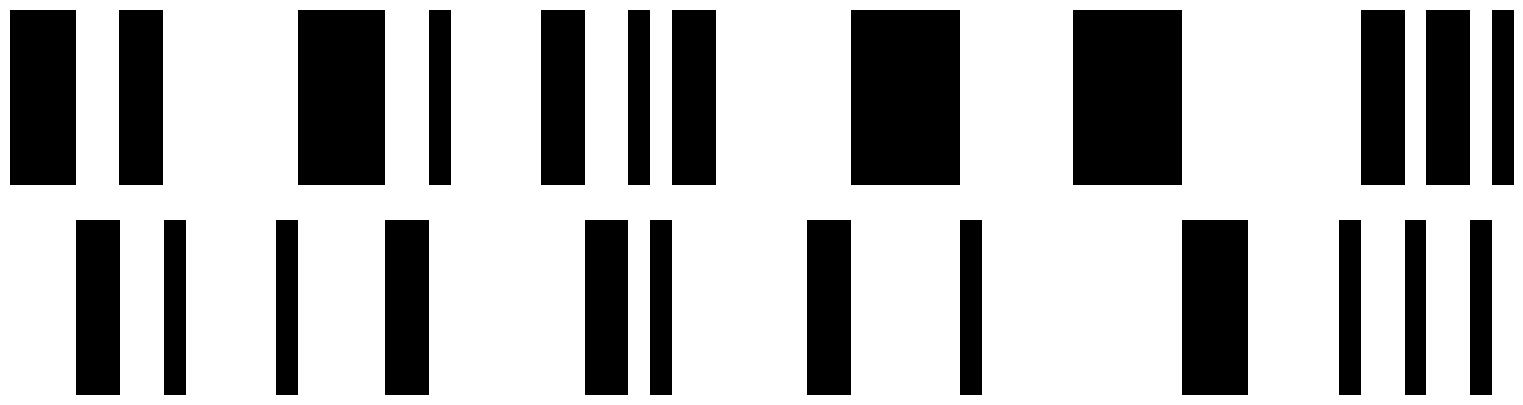

In [4]:
n = 6
masks = [mask(1) for _ in range(n)]

fig, axs = plt.subplots(2, n, figsize=(20, 5))
for i, (context_mask, target_mask) in enumerate(masks):
    # Ensure mask is 2D for imshow
    context_mask = context_mask.repeat_interleave(IQ_PATCH_SIZE[0] // IQ_PATCH_SIZE[1], dim=2)
    target_mask = target_mask.repeat_interleave(IQ_PATCH_SIZE[0] // IQ_PATCH_SIZE[1], dim=2)

    mask_img = context_mask.numpy().reshape(context_mask.shape[-2], context_mask.shape[-1])
    target_img = target_mask.numpy().reshape(target_mask.shape[-2], target_mask.shape[-1])
    axs[0, i].imshow(mask_img, cmap='gray')
    axs[1, i].imshow(target_img, cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].axis('off')

In [5]:
from data.hdf5_iqfmfolder import HDF5IQDataset
from data.hdf5_imagefolder import HDF5ImageFolder
from torchvision import transforms
from lightly.transforms.ijepa_transform import IJEPATransform
from data.hdf5_iqfmfolder import IQTransformations, ExclusiveComposeTransforms, IQ_NORMALIZE

import os
import numpy as np

transform = IJEPATransform(input_size=IQ_INPUT_SIZE) # RandomResizedCrop, RandomHorizontalFlip, ToTensor


iq_tf = IQTransformations(
            noise_std=0,
            time_shift_max=60,
            amplitude_scale=(1, 1),
            phase_shift_max=0,
            apply_prob=0.9,
        )
normalize = transforms.Normalize(
        mean=IQ_NORMALIZE['mean'],
        std=IQ_NORMALIZE['std']
    )
# ch_drop = ChannelDropping(drop_prob=0)
# ch_mask = ChannelMasking(mask_prob=0.9, mask_length=160)
iq_transform = ExclusiveComposeTransforms([iq_tf])


iq = True
if iq == True:
    ds = HDF5IQDataset(root="./data/iqfm-val.h5", transform=iq_transform, inter_channel=True)
else:
    ds = HDF5ImageFolder(root="./data/imagenet-100-train.h5")

Selected data angle of arrival


In [6]:
# convert numpy
see = ds[9][0]
see_np = np.array(see)

print(see_np.shape)  # I

(2, 256, 256)


(256, 256, 2) (256, 256, 1) (256, 256, 1)
(256, 256, 2) (256, 256, 1) (256, 256, 1)
(256, 256, 2) (256, 256, 1) (256, 256, 1)
(256, 256, 2) (256, 256, 1) (256, 256, 1)
(256, 256, 2) (256, 256, 1) (256, 256, 1)
(256, 256, 2) (256, 256, 1) (256, 256, 1)


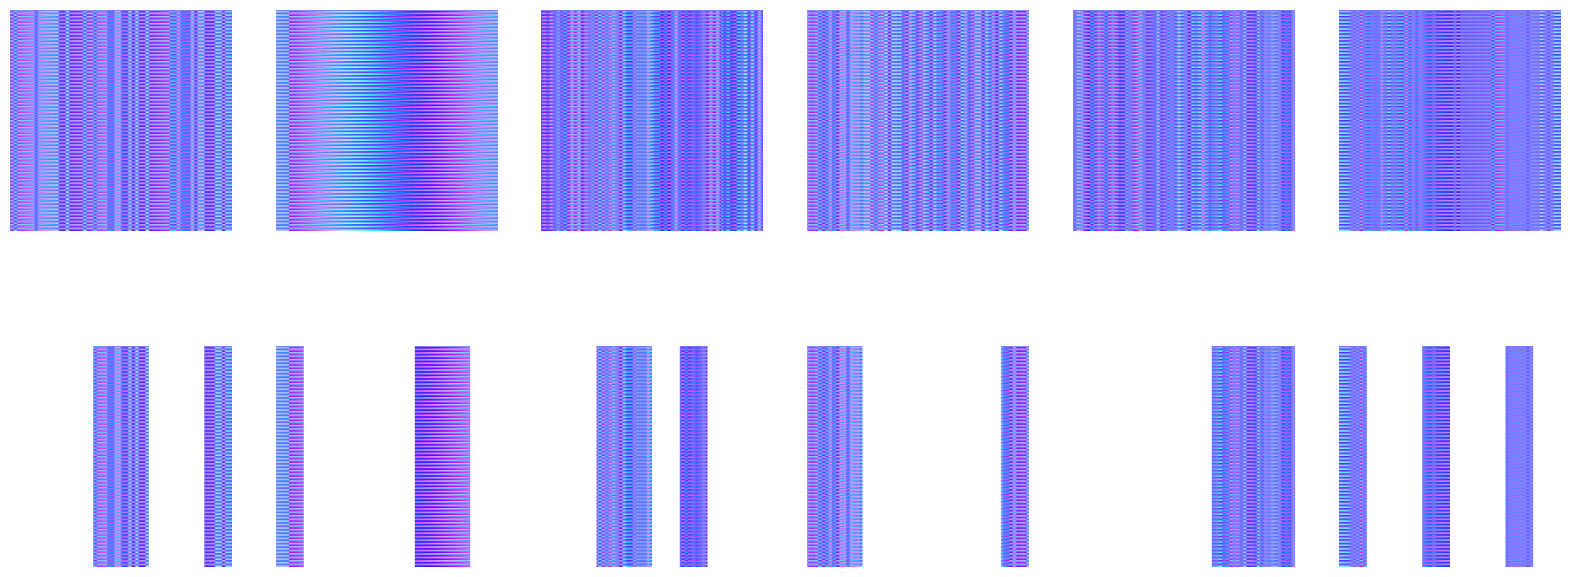

In [7]:
import torch.nn.functional as F

fig, axs = plt.subplots(2, n, figsize=(20, 8))  # 2 rows now
for i, (context_mask, target_mask) in enumerate(masks):
    # 1) Load & size the image
    im, _ = ds[i+20000]

    if iq:
        im = np.array(im)
        # permute
        im = im.transpose(1, 2, 0)  # (H, W, C)
        im = (im - im.min()) / (im.max() - im.min()) * 255.0

        context_mask = context_mask.repeat_interleave(2, dim=2)
        target_mask = target_mask.repeat_interleave(2, dim=2)
    else:
        im = transform(im)
        im = np.array(im, dtype=np.uint8)  # (H, W, C)
    # print(im.shape, context_mask.shape)

    H, W = im.shape[:2]

    # 2) Upsample masks
    _, _, h, w = context_mask.shape
    assert H % h == 0 and W % w == 0
    h_rep, w_rep = H // h, W // w
    # print(H, W, h, w, h_rep, w_rep)



    im_mask = context_mask.repeat_interleave(h_rep, dim=2)\
                           .repeat_interleave(w_rep, dim=3)
    t_mask  = target_mask.repeat_interleave(h_rep, dim=2)\
                          .repeat_interleave(w_rep, dim=3)


    im_mask = im_mask.squeeze().numpy()[..., None]
    t_mask = t_mask.squeeze().numpy()[..., None]
    print(im.shape, im_mask.shape, t_mask.shape)
    # 3) Apply mask
    masked_im = im * im_mask + 255 * t_mask
    masked_im = masked_im.clip(0, 255).astype(np.uint8)
    im = im.clip(0, 255).astype(np.uint8)

    if iq:
        white_chan = 255 * np.ones((im.shape[0], im.shape[1], 1), dtype=np.uint8)
        im = np.concatenate([im, white_chan], axis=-1)
        masked_im = np.concatenate([masked_im, white_chan], axis=-1)
    
    # --- plot ---
    axs[0, i].imshow(im)       # original upscaled
    axs[0, i].axis('off')
    axs[1, i].imshow(masked_im)   # masked upscaled
    axs[1, i].axis('off')

In [8]:
# !zip -r example_masked_images.zip example_masked_images